<a href="https://colab.research.google.com/github/Dheer24/DheerMehta_ACMResearchTasks/blob/main/Copy_of_interview_eda_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [ ]:
import pandas as pd  # pandas ke pass hai ability to read a csv file ( but in messy raw text ) and tranforms into excel like data
import numpy as np  # used for heavy maths main feature is that uses np.nan ( mtlb whenever a data set is null this helps us to tells ki it is not havving any number )
import matplotlib.pyplot as plt # produces thoda ugly charts and takes a lot of code
import seaborn as sns # advance type of matplotlib solves the ugly problem makes beautiful things in 1/small line of code

# so why to use matplot if we have seaborn already is obv q
# ans is because seaborn draws the beautiful art but matplotlib provides the canvas (controlling the image size and layout)
print("Libraries imported successfully!")

Libraries imported successfully!


## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [31]:
# df mtlb data frame and it is inbuilt object in pandas
# df is like excel of python
df = pd.read_csv('netflix_titles.csv')  # dataset ko read karke pandas dataframe ke (df) mein save kar rahe hain

# display is fxn into google colab and jupyter notebooks if u use std python ka print(df) it makes table look messy
display(df.head(3)) # data properly load hua ya nahi, ye check karne ke liye shuru ki 3 rows dekhte hain

# head(3) tells pandas to go to the absolute top of the dataset (index 0) and gets us exactly the first 3 rows
# if you ever want to see the very bottom of the dataset, you can use .tail(3)

print(f"This catalogue contains {df.shape[0]} titles and {df.shape[1]} columns.")

# df.shape() humko ek tuple deta hai which has exact dimensions of the dataframe
# like this (8807, 12)

# so 8807 is 0th index ie shape[0] so and it is no of rows and 12 is similarly no of columns

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


This catalogue contains 8807 titles and 12 columns.


### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [32]:
# har column ka data type check karte hain (kya wo text hai ya number?)
print("--- Data ki Kundali (Info) ---")

# . operator says us to look inside df object to find a specific tool

df.info()

# .info() is an inbuilt function belonging exclusively to pandas dataframes.
# it technically returns none instead, it automatically prints a report to your screen
# it gives us all info ie the names of all the columns, exactly how many non-empty values are in each column
# and what type of data (datattype) is living in them (eg text, integers, or decimals)

# ye check karte hain ki kis column mein kitna data missing (khali) hai
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# you are asking the computer a very specific multi-step question
# look at my entire table find every single empty box and tell me exactly how many empty boxes exist in each column



--- Data ki Kundali (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

--- Missing Values Check ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
du

### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [33]:
# sirf numerical columns ka math aur statistics (min, max, average) nikalte hain
display(df.describe())

# descibe is a built-in pandas method for dataframes
# it scans all your columns, completely ignores any columns that hold text (like movie titles), finds the numerical columns (like release year)
# and instantly runs heavy statistics on them (calculating the mean, standard deviation, minimum, and maximum).

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [35]:

# agar director ya date_added missing hai, toh aisi rows ka analysis karna mushkil hai.
# hum dropna() use karke un rows ko hata dete hain taaki data clean ho jaye.

df_clean = df.dropna(subset=['director', 'date_added'])

print(f"Original data mein {df.shape[0]} rows the.")
print(f"Clean karne ke baad ab {df_clean.shape[0]} rows bache hain.")

Original data mein 8807 rows the.
Clean karne ke baad ab 6173 rows bache hain.


## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [36]:
# date_added column abhi text string hai. isme se extra spaces (strip) hata kar,
# isko proper date-time format mein badal rahe hain.
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# takes human text (like september 9, 2019) and translates it into a standard computer timestamp (yyyy-mm-dd).
# .str means that treat the data inside this column as literal text strings

# a text-editing tool that mathematically shaves off any accidental invisible spaces at the very beginning or end of the word
# (like 2019 becomes 2019)
# if we dont do this, the time machine will crash because it doesnt understand blank spaces.

# ab ye proper date ban chuka hai, toh isme se sirf saal (year) nikal kar
# ek naya column year_added bana rahe hain.
df['year_added'] = df['date_added'].dt.year

# check karte hain ki data type sach mein change hua ya nahi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 894.6+ KB


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [38]:
# tv shows ko hata kar ek naya table banate hain jisme sirf movie ho
movies_only = df[df['type'] == 'Movie'].copy()

# whenever you see a dataframe variable ie with this syntax df[ ... ]
# it means filter this table based on the rule inside

# df[type] == movie
# this is called a boolean mask.

# it looks at the type column and checks every single row.

# the == (double equals) is the mathematical operator for comparison (asking is this exactly equal to?)
# if it is a movie, it gets a true. if it is a tv show, it gets a false,the outer brackets then throw away all the false rows

# it is always safe to create a copy so that anything u do chnges in the main file doesnt hamper the og file

# error fix agar kisi movie ka duration missing (nan) hai, toh integer conversion crash ho jayega.
# isliye hum pehle un rows ko drop kar denge jahan duration khali hai.
movies_only = movies_only.dropna(subset=['duration'])

# ab duration mein se min hatakar usko proper integer (int) banate hain
movies_only['duration_minutes'] = movies_only['duration'].str.replace(' min', '').astype(int)

# movies_only[duration] scans the duration column.

# .str.replace( min, ) treat it as text, find the exact characters min, and replace them with (absolutely nothing/delete them). 90 min becomes 90.

# .astype(int) as-type stands for assign type. even though the data is now just the characters 90
# the computer still thinks it is a word. .astype(int) forces the system architecture to reclassify that data as an integer (a whole number)
# which finally allows us to use math to sort the movies by length.

# movies ko unki length ke hisaab se descending order mein sort karke top 5 nikalte hain
top_5 = movies_only.sort_values(by='duration_minutes', ascending=False).head(5)

# final result screen par display karte hain
display(top_5[['title', 'duration_minutes']])

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233


## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

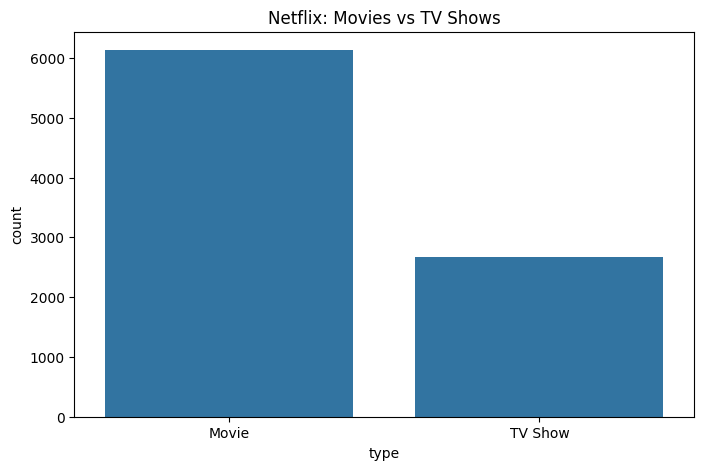

In [39]:
# level 6 matplotlib canvas provide karta hai, aur seaborn actual graph draw karta hai.

# plt.figure() humare canvas (board) ka size tay karta hai (width=8, height=5)
plt.figure(figsize=(8, 5))

# sns.countplot automatically count karta hai ki type column mein kitne movies aur kitne shows hain
#sns calls the seaborn library
sns.countplot(x='type', data=df)
#x axis pe type aayega
#aur ye aayega from data

# graph ko ek title de rahe hain
plt.title("Netflix: Movies vs TV Shows")

# plt.show() final drawing ko screen par print karta hai
plt.show()

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

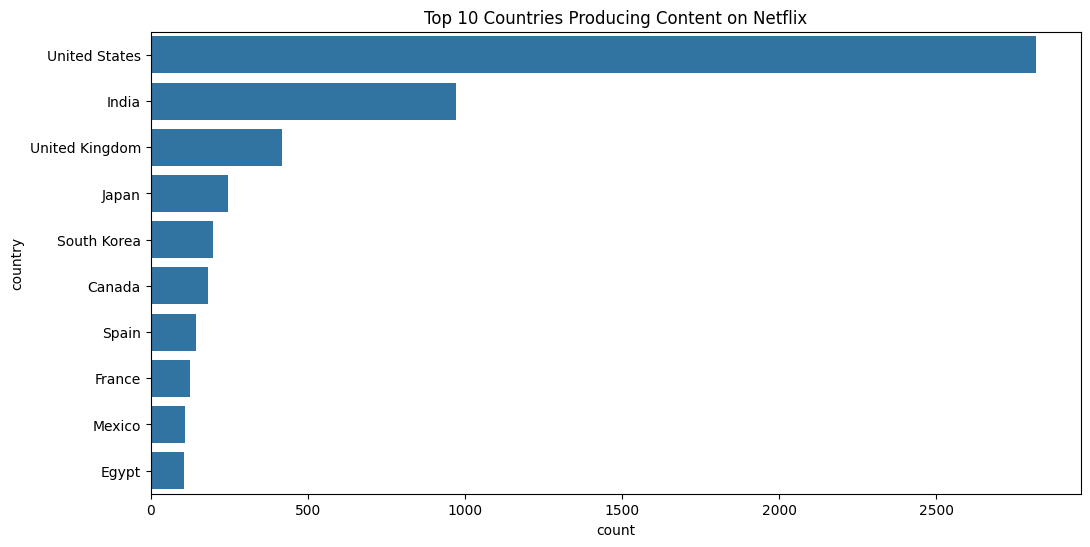

In [ ]:
# Level 7: Kis desh ne sabse zyada content banaya?

plt.figure(figsize=(12, 6))

# y='country' likha hai taaki bar chart horizontal bane
# order=... use karke hum bol rahe hain ki sirf Top 10 countries ko hi graph mein dikhao
#also tells Seaborn how to arrange the bars if we don't use this, Seaborn will just throw them on the graph randomly

sns.countplot(y='country', data=df, order=df['country'].value_counts().index[0:10])

#df['country'].value_counts()
#Pandas math function it looks at the country column and counts every single entry

#slicing the sorted list from 0 to 10 ie [0:10]

plt.title("Top 10 Countries Producing Content on Netflix")
plt.show()

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

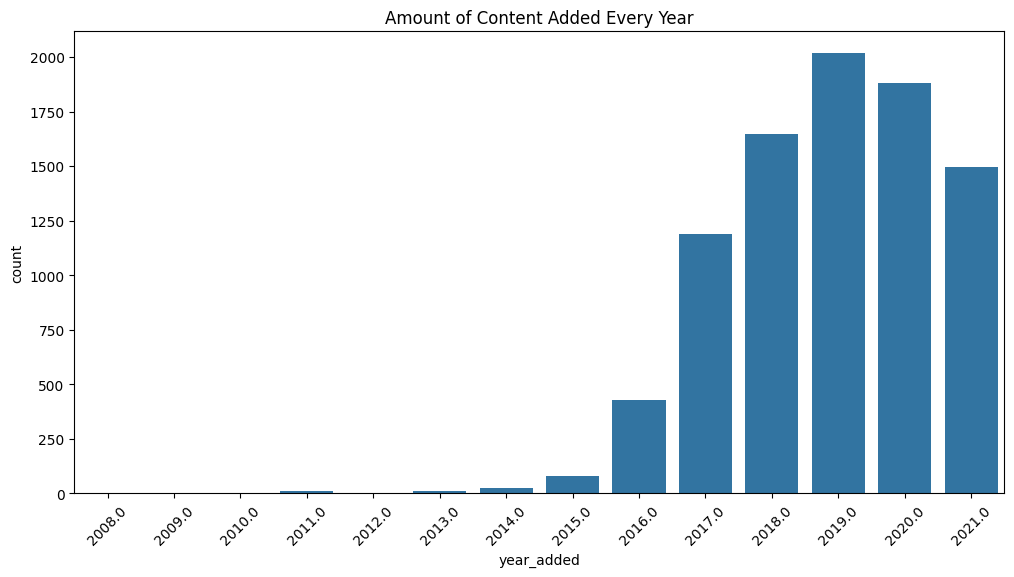

In [ ]:
# Level 8: Netflix ne kis saal sabse zyada content add kiya?
# in level 4 mein 'year_added' ka naya column banaya tha abbb wo yahan use hoga!

plt.figure(figsize=(12, 6))
sns.countplot(x='year_added', data=df)

# plt.xticks x-axis ke labels (saal) ko 45 degrees par ghuma deta hai taaki wo ek dusre par overlap na karein.
plt.xticks(rotation=45)

plt.title("Amount of Content Added Every Year")
plt.show()

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

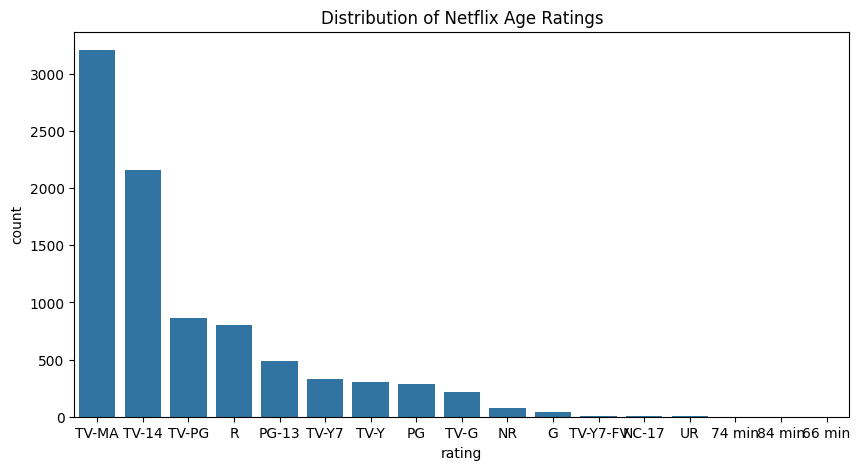

In [41]:
# level 9 netflix par kis type ki ratings sabse zyada hain (jaise tv-ma, pg-13)?

plt.figure(figsize=(10, 5))

# hum rating column ka count plot bana rahe hain aur usko descending order mein sort kar rahe hain
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index)

plt.title("Distribution of Netflix Age Ratings")
plt.show()

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

/tmp/ipykernel_1125/1198455984.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='listed_in', data=india_data, order=india_data['listed_in'].value_counts().index[0:5], palette='magma')


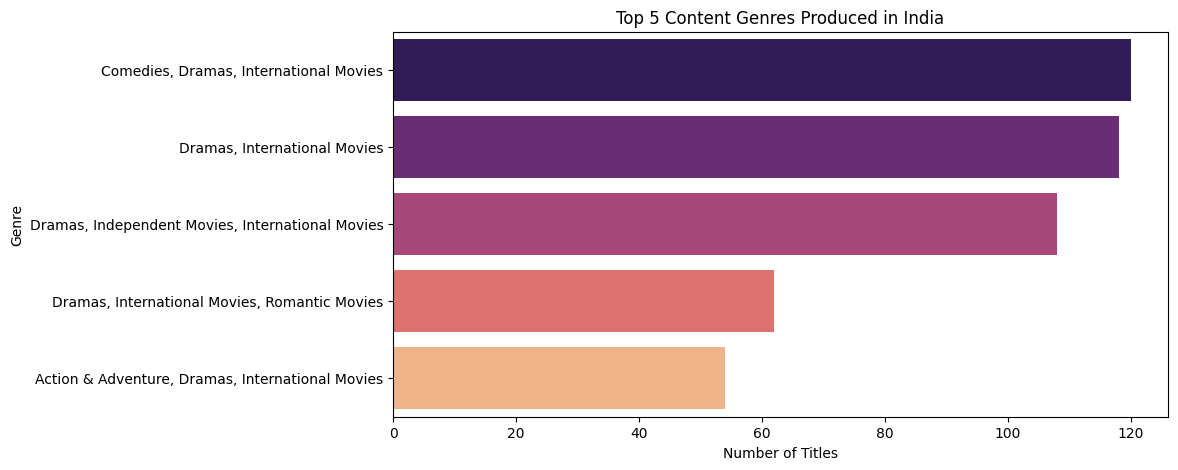

--------------------------------------------------


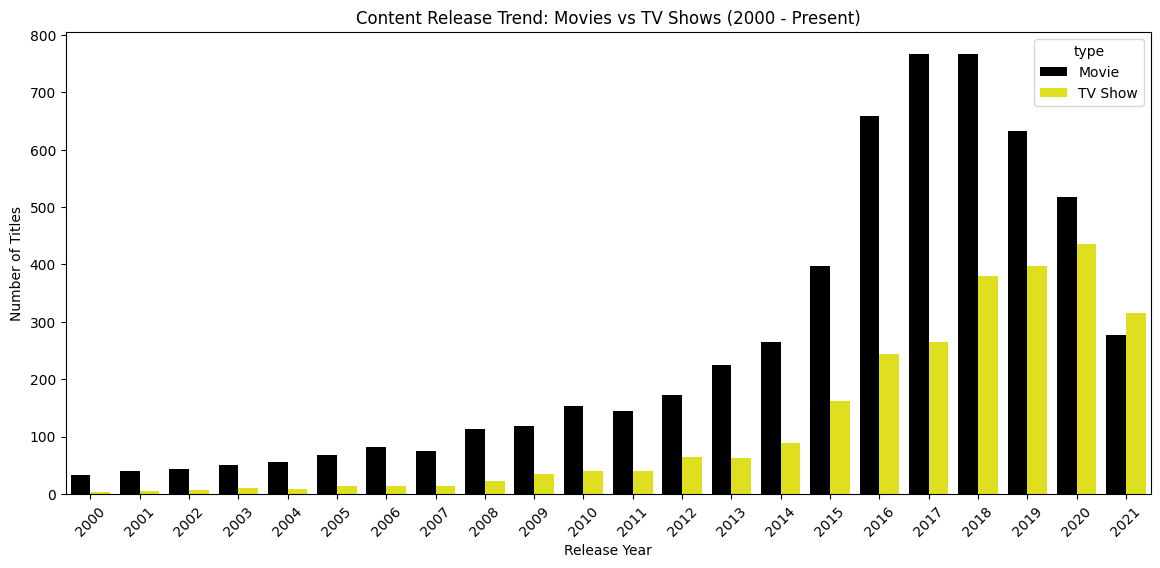

In [42]:
# final task open exploration

# plot 1 the india story - top 5 genres in india
# netflix par india ka content kaisa hai? hum sirf india ka data filter karke uske top genres dekhenge
# yahan fir se boolean mask lagaya hai jahan bhi country india ke barabar hai wo data alag kar lo
india_data = df[df['country'] == 'India']

# canvas ka size thoda choda (wide) rakha hai taaki labels fit ho sakein
plt.figure(figsize=(10, 5))

# countplot sidha rows ko ginta hai koi heavy math khud nahi karni padti
# y=listed_in likhne se bars horizontal (lete hue) bante hain jisse lambe text padhne mein asaan hote hain
# order parameter ensure karta hai ki sirf top 5 categories hi draw ho aur wo bhi highest se lowest
sns.countplot(y='listed_in', data=india_data, order=india_data['listed_in'].value_counts().index[0:5], palette='magma')

# if we did not write palette= seaborn would have just drawn a bunch of plain solid-colored bars ie boring
# by typing palette=magma we gave seaborn a specific paintbrush
# seaborn has dozens of these built-in paintbrushes with names like viridis, rocket, pastel, and dark

# in teen lines se hum graph aur dono axis (x aur y) ko headings de rahe hain taaki user ko samajh aaye graph kiska hai
plt.title("Top 5 Content Genres Produced in India")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

# ek line draw karne ke liye taaki console ka output clean aur separate dikhe
print("-" * 50)

# plot 2 the timeline - content release trends (2000 onwards)
# kya netflix purani movies zyada rakhta hai ya nayi? lets check the release years
# dataset mein 1920s ka data bhi hai jo graph ko bahut lamba aur ugly bana dega
# hum sirf 2000 ke baad ka data le rahe hain taaki graph clean bane aur modern trends dikhein
recent_years = df[df['release_year'] >= 2000]

# is baar graph thoda aur bada (14 width) banaya hai kyunki 20 saal ka data dikhana hai
plt.figure(figsize=(14, 6))

# we use curly brackets {} to create a dictionary of exact rules
# dictionary hume power deti hai ki hum khud force karein ki movie black ho aur tv show yellow
sns.countplot(x='release_year', hue='type', data=recent_years, palette={'Movie': 'black', 'TV Show': 'yellow'})

# hue ka mtlb hee hota ha color
# and see upper rhs mai box jaisa (legend) hai usme bola hai black is movie and yellow is tv show it is due to this feature of hue=type
# seaborn ye guide box automatically banata hai jab hum hue command pass karte hain

# graph labels add kar rahe hain
plt.title("Content Release Trend: Movies vs TV Shows (2000 - Present)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

# x-axis par saal (years) ko 45 degree ghuma diya taaki text overlap na ho aur kaala dhabba na bane
plt.xticks(rotation=45)
plt.show()